---
# Case Study: Nevada Basin Thickness from FFTs

## Learning Objectives:
- See how FFTs can be used to analyze real world geophysical data
- Perform isostatic correction to isolate shallow (basin) gravity signal
- Use inversion to estimate basin thickness
- See how aliasing affects basin model


In [2]:

from pathlib import Path
import sys

_ROOT    = Path.cwd().parent.parent.parent   # src/demos/fft/ -> project root
DATAPATH = _ROOT / "data"

if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
from src.common.grids.grid_io import read_pacs_grd

import matplotlib.pyplot as plt
%matplotlib inline

import geopandas as gpd
from shapely.geometry import box
from pyproj import CRS

from ipywidgets import interact, IntSlider
from src.inversion.parker_oldenburg import parker_oldenburg

from scipy.fft import fft2 as _fft2, ifft2 as _ifft2, fftfreq as _fftfreq
from scipy.fft import rfft as _rfft2, rfftfreq as _rfftfreq2


from ipywidgets import interact, FloatSlider, IntSlider
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True
})


## Part 1 — Nevada Bouguer Gravity Anomaly
We now apply the same concepts to the **Nevada Complete Bouguer Gravity** dataset
(NEVCBA, USGS/PACES), a gridded compilation of ground gravity measurements across
the Basin-and-Range Province.

- Grid spacing: 2 km × 2 km (Lambert Conformal Conic projection)
- Anomaly type: Complete Bouguer (terrain-corrected)
- Nyquist wavelength: **4 km**
- Spatial extent: ~564 km E–W × 794 km N–S


### 1.1 Load and inspect the gravity grid

**Objective:** load the gridded ASCII file and confirm the spatial metadata
before plotting.


In [3]:
crs_lcc = CRS.from_proj4(
    "+proj=lcc "
    "+lat_1=33 +lat_2=45 "
    "+lat_0=0 "
    "+lon_0=-117 "
    "+x_0=0 +y_0=0 "
    "+units=km +datum=WGS84"
)
print(crs_lcc)


grd = read_pacs_grd(DATAPATH / "nevboug.grd.txt")
gravity = grd.grid   # shape (nrows, ncols)
x       = grd.x      # km, west–east  (LCC projection)
y       = grd.y      # km, south–north

print(f'Grid shape : {gravity.shape}  ({grd.meta["nrows"]} rows × {grd.meta["ncols"]} cols)')
print(f'X range    : {x.min():.1f} – {x.max():.1f} km')
print(f'Y range    : {y.min():.1f} – {y.max():.1f} km')
print(f'Gravity    : {np.nanmin(gravity):.2f} – {np.nanmax(gravity):.2f} mGal')


+proj=lcc +lat_1=33 +lat_2=45 +lat_0=0 +lon_0=-117 +x_0=0 +y_0=0 +units=km +datum=WGS84 +type=crs
Grid shape : (397, 282)  (397 rows × 282 cols)
X range    : -280.9 – 281.1 km
Y range    : 4177.1 – 4969.1 km
Gravity    : -275.88 – -64.29 mGal


### 1.2 Background layers — hillshade and state boundaries

Before plotting the gravity we prepare two orientation layers:

1. **Hillshade** — ETOPO 30-arcsecond topography reprojected to LCC and illuminated
   from the NW (azimuth 315°, altitude 45°).  Basins appear dark (low elevation);
   ranges appear bright.  Adding hillshade to a potential-field map helps the eye
   correlate gravity anomalies with topography.

2. **State boundaries** — clipped to the gravity grid extent and reprojected to LCC.

Both are computed once here and reused on all subsequent maps.


In [4]:
import netCDF4
from pyproj import Transformer
from scipy.interpolate import RegularGridInterpolator

from src.common.plotting.hillshade import hillshade

# --- Load ETOPO and reproject to LCC grid ---
ds = netCDF4.Dataset(DATAPATH / "topography" / "ETOPO_2022_v1_30s_N90W180_surface.nc")
lat_all = ds.variables['lat'][:]
lon_all = ds.variables['lon'][:]

# Extract subset spanning the gravity grid (with margin)
lat_mask = (lat_all >= 34.5) & (lat_all <= 42.5)
lon_mask = (lon_all >= -121.0) & (lon_all <= -113.5)
lat_idx = np.where(lat_mask)[0]
lon_idx = np.where(lon_mask)[0]
z_etopo = np.array(ds.variables['z'][lat_idx[0]:lat_idx[-1]+1,
                                      lon_idx[0]:lon_idx[-1]+1], dtype=float)
lat_sub = np.array(lat_all[lat_idx])
lon_sub = np.array(lon_all[lon_idx])
ds.close()

# Inverse-project the gravity grid from LCC (km) back to lon/lat
to_lonlat = Transformer.from_crs(crs_lcc, 'EPSG:4326', always_xy=True)
XX, YY = np.meshgrid(x, y)
LON_grd, LAT_grd = to_lonlat.transform(XX.ravel(), YY.ravel())
LON_grd = LON_grd.reshape(XX.shape)
LAT_grd = LAT_grd.reshape(XX.shape)

# Bilinear interpolation of ETOPO onto the gravity grid
interp_topo = RegularGridInterpolator(
    (lat_sub, lon_sub), z_etopo,
    method='linear', bounds_error=False, fill_value=np.nan
)
topo = interp_topo(
    np.stack([LAT_grd.ravel(), LON_grd.ravel()], axis=1)
).reshape(XX.shape)

# --- Hillshade topography for visualization ---
hs = hillshade(np.where(np.isnan(topo), 0.0, topo),
               dx_m=grd.meta['dx'] * 3e2,
               dy_m=grd.meta['dy'] * 3e2)

states = gpd.read_file(DATAPATH / "political" / "tl_2025_us_state.shp")
states_lcc = states.to_crs(crs_lcc)

bbox = box(x.min(), y.min(), x.max(), y.max())
states_clip = states_lcc.clip(bbox)


In [5]:
def plot_gravity_profiles(x_km, y_km, datasets, y_targets=(4600, 4700)):
    """
    Plot E-W gravity profiles at two y-values on separate subplots.

    Parameters
    ----------
    x_km     : 1-D array, easting coordinates (km)
    y_km     : 1-D array, northing coordinates (km)
    datasets : list of (label, 2-D array, colour) tuples
    y_targets: sequence of northing values (km) at which to extract profiles
    """
    n = len(y_targets)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, y_target in zip(axes, y_targets):
        row = int(np.argmin(np.abs(y_km - y_target)))
        y_actual = y_km[row]
        for label, data, colour in datasets:
            ax.plot(x_km, data[row, :], color=colour, label=label)
        ax.set_ylabel('Gravity (mGal)')
        ax.set_title(f'E\u2013W profile at y \u2248 {y_actual:.0f} km')
        ax.legend(fontsize=8)
        ax.grid(True)

    axes[-1].set_xlabel('Easting (km, LCC)')
    plt.tight_layout()
    plt.show()


### 1.3 Nevada Complete Bouguer Gravity map

**Objective:** familiarise yourself with the spatial pattern of the Bouguer anomaly
before any corrections are applied.

The **Complete Bouguer anomaly** corrects for:
- the free-air effect of elevation,
- the gravitational attraction of the rock slab between the station and the geoid,
- terrain corrections for nearby topographic relief.

What remains reflects lateral density variations in the crust and upper mantle.


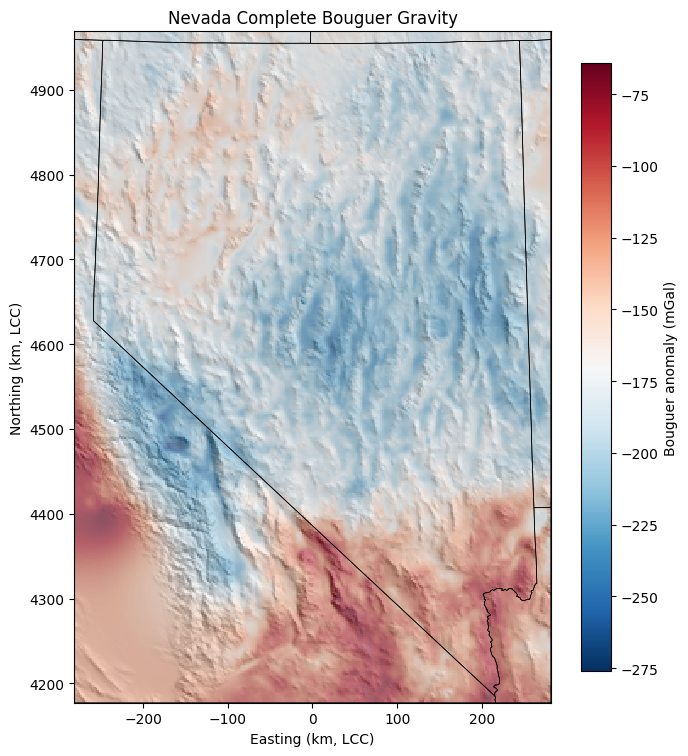

In [6]:
fig, ax = plt.subplots(figsize=(7, 9))

img = ax.pcolormesh(x, y, gravity, cmap='RdBu_r', shading='auto')

ax.pcolormesh(
    x, y, hs,
    cmap='gray', shading='auto',
    vmin=0, vmax=1,
    alpha=0.45,
)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.autoscale(False)

states_clip.boundary.plot(ax=ax, color='black', linewidth=0.5)

plt.colorbar(img, ax=ax, label='Bouguer anomaly (mGal)', shrink=0.7)
ax.set_xlabel('Easting (km, LCC)')
ax.set_ylabel('Northing (km, LCC)')
ax.set_title('Nevada Complete Bouguer Gravity')
ax.set_aspect('equal')
plt.grid(False)
plt.tight_layout()
plt.show()


> **Key observations:**
> - The overall trend is **negative** across Nevada (−250 to −100 mGal), reflecting
>   thick, low-density crust typical of the extended Basin-and-Range crust.
> - There is a pronounced **NW–SE gradient**: gravity increases toward the eastern
>   edge (Colorado Plateau) and decreases toward the Sierra Nevada.  This long-wavelength
>   signal is dominated by crustal thickness variations, not by individual basins.
> - Individual basin–range pairs produce gravity "stripes" with wavelengths of 20–50 km,
>   but they are hard to see against the regional background — the same problem we
>   observed in the synthetic model.


### 1.4 Aliasing on real data — the effect of station spacing

**Objective:** demonstrate how coarsening the sampling of the real Nevada gravity
grid produces aliasing of the basin-scale signal.

The slider controls the effective station spacing (in km).  At each setting the
notebook subsamples the full-resolution 2 km grid, plots the resulting map, and
shows the E-W power spectrum with the new Nyquist wavelength marked.

> **Questions to consider:**
> - At what spacing do the individual NV basins (~20–50 km wide) begin to alias?
> - Where does the aliased energy appear in the spectrum?
> - How does the apparent sediment thickness from the inversion change with spacing?


In [7]:
from scipy.fft import rfft as _rfft, rfftfreq as _rfftfreq

def _ew_spectrum(grid, dx_km):
    """Mean E-W power spectrum of a 2-D grid."""
    ny_g, nx_g = grid.shape
    k  = _rfftfreq(nx_g, d=dx_km); k[0] = np.nan
    wl = 1.0 / k
    ps = np.zeros(len(k))
    n  = 0
    for row in grid:
        if np.isnan(row).all(): continue
        r = row.copy(); r[np.isnan(r)] = np.nanmean(r)
        r -= np.polyval(np.polyfit(np.arange(nx_g), r, 1), np.arange(nx_g))
        ps += np.abs(_rfft(r))**2; n += 1
    return wl, ps / max(n, 1)


def show_aliasing(spacing_km=2):
    step = max(1, int(round(spacing_km / grd.meta['dx'])))
    actual_dx = step * grd.meta['dx']   # true spacing after rounding
    nyquist   = 2 * actual_dx            # km

    # Subsample gravity grid
    g_sub  = gravity[::step, ::step]
    x_sub  = x[::step]
    y_sub  = y[::step]
    hs_sub = hs[::step, ::step]

    # E-W power spectra of Bouguer gravity: full-res vs subsampled
    wl_full, pw_full = _ew_spectrum(gravity, grd.meta['dx'])
    wl_sub,  pw_sub  = _ew_spectrum(g_sub,   actual_dx)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8),
                              gridspec_kw={'width_ratios': [1, 1.3]})

    # ── Map ──────────────────────────────────────────────────────────
    ax = axes[0]
    vmin, vmax = np.nanpercentile(gravity, [2, 98])
    ax.pcolormesh(x_sub, y_sub, g_sub, cmap='RdBu_r', shading='auto',
                  vmin=vmin, vmax=vmax)
    ax.pcolormesh(x_sub, y_sub, hs_sub, cmap='gray', shading='auto',
                  vmin=0, vmax=1, alpha=0.35)
    states_clip.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_xlim(x.min(), x.max()); ax.set_ylim(y.min(), y.max())
    ax.set_aspect('equal')
    ax.set_title(f'Bouguer gravity\n(spacing = {actual_dx:.0f} km, '
                 f'Nyquist = {nyquist:.0f} km)')
    ax.set_xlabel('Easting (km, LCC)')
    ax.set_ylabel('Northing (km, LCC)')

    # ── Power spectrum ────────────────────────────────────────────────
    ax = axes[1]
    ax.loglog(wl_full, pw_full, 'k',  lw=0.8, alpha=0.5, label='Full res (2 km)')
    ax.loglog(wl_sub,  pw_sub,  'C1', lw=1.0,             label=f'Subsampled ({actual_dx:.0f} km)')
    ax.axvline(nyquist, color='C1', ls='--', lw=1.2,
               label=f'Nyquist = {nyquist:.0f} km')
    ax.axvline(2 * grd.meta['dx'], color='k', ls=':', lw=0.8,
               label=f'Full-res Nyquist = {2*grd.meta["dx"]:.0f} km')
    ax.axvspan(20, 60, alpha=0.10, color='steelblue',
               label='Typical basin width (20–60 km)')
    ax.set_xlim(3, 600); ax.set_ylim(1e2, None)
    ax.set_xlabel('Wavelength (km)')
    ax.set_ylabel('Power (mGal² km)')
    ax.set_title('E–W power spectrum (Bouguer gravity)')
    ax.legend(fontsize=8)

    plt.suptitle(f'Aliasing demo — station spacing {actual_dx:.0f} km',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Spacing: {actual_dx:.0f} km  |  '
          f'Nyquist: {nyquist:.0f} km  |  '
          f'Grid size: {g_sub.shape[0]}×{g_sub.shape[1]}')
    if nyquist > 20:
        print(f'⚠️  Nyquist ({nyquist:.0f} km) > 20 km: '
              f'basin-scale signal is aliased.')
    else:
        print('✓  Nyquist < 20 km: basin-scale basins are resolved.')


interact(
    show_aliasing,
    spacing_km=FloatSlider(
        min=2, max=30, step=2, value=2,
        description='Spacing (km)',
        style={'description_width': 'initial'},
    )
);

interactive(children=(FloatSlider(value=2.0, description='Spacing (km)', max=30.0, min=2.0, step=2.0, style=Sl…

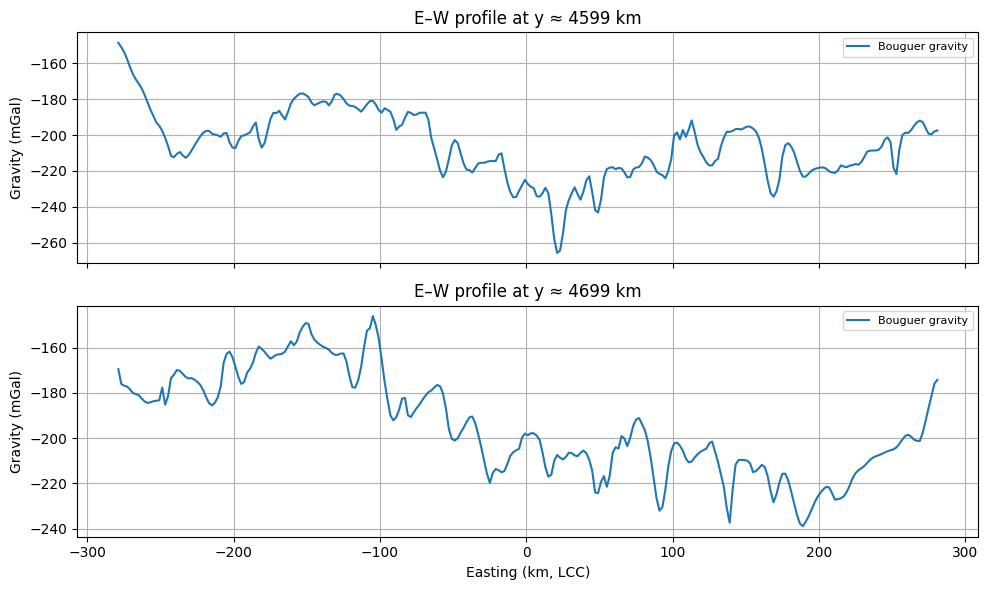

In [8]:
# E–W gravity profiles at y = 4600 and 4700 km — Bouguer gravity
plot_gravity_profiles(
    x, y,
    [('Bouguer gravity', gravity, 'C0')],
)


> **Key observations:**
> - At 2–4 km spacing the individual graben signatures are clearly resolved.
> - At ~10 km spacing (Nyquist 20 km) the smallest basins begin to blur; the
>   power spectrum shows the Nyquist cut-off approaching the basin-scale band.
> - At 16 km spacing (Nyquist 32 km) the 20 km basins alias: the power spectrum
>   develops spurious peaks at longer wavelengths and the map shows "phantom"
>   basin-scale structure that does not exist in the geology.
> - This is exactly the aliasing we diagnosed in the synthetic model — the same
>   physics, but now visible in real data with real consequences for interpretation.


---
## Part 2 — Isostatic Correction

The long-wavelength Bouguer gravity signal over Nevada is dominated by **isostatic
compensation**: the crust is thickened or thinned, and the resulting mass deficit
at the surface is compensated by a corresponding root (or anti-root) at the Moho.

We remove this effect using an **Airy isostasy model** implemented in the spectral
domain.  The predicted Moho contribution is computed via the upward-continuation
filter, then subtracted from the Bouguer anomaly to leave the **isostatic residual**
$g_\text{iso}$, which reflects shallow crustal density variations rather than
crustal thickness.


### 2.1 Compute the isostatic residual

**Objective:** apply the spectral isostatic correction and confirm that the result
has zero mean and reduced long-wavelength power.

The Parker (1973) upward-continuation filter at depth $T_0$ (mean Moho depth, here
35 km) is:
$$\hat{g}_\text{root}(\mathbf{k}) = e^{-|\mathbf{k}| T_0}\, \hat{g}(\mathbf{k})$$

Subtracting $g_\text{root}$ from the observed Bouguer gravity leaves the isostatic
residual.

> **Note:** NaN values at survey edges are filled with the grid mean before the FFT
> (NaNs propagate through the transform and poison all output), then restored
> in the residual.


In [9]:
from scipy.fft import fft2, ifft2, fftfreq

# Constants
G = 6.67430e-11      # m^3 kg^-1 s^-2
drho = 2700 - 3330   # kg/m^3 (crust - mantle, negative)
T0 = 35e3            # mean crustal thickness, m

# Grid spacing in metres
dx = grd.meta['dx'] * 1e3
dy = grd.meta['dy'] * 1e3

ny, nx = gravity.shape

# NaN mask — track survey edges so we can restore them afterwards
nan_mask = np.isnan(gravity)

# Fill NaN with the grid mean before FFT (NaNs poison the entire transform)
g_filled = gravity.copy()
g_filled[nan_mask] = np.nanmean(gravity)

# Convert mGal -> m/s^2 for SI-consistent calculation
g_si = g_filled * 1e-5

# 2-D FFT of the Bouguer gravity
G_obs = fft2(g_si)

# Radial wavenumber grid (rad/m)
kx = 2 * np.pi * fftfreq(nx, d=dx)
ky = 2 * np.pi * fftfreq(ny, d=dy)
KX, KY = np.meshgrid(kx, ky)
k = np.sqrt(KX**2 + KY**2)
k[0, 0] = 1e-10   # avoid singularity at DC

# Upward-continuation (Parker) filter: gravity effect of an interface
# at depth T0 with density contrast drho.
#   g_root(k) = 2π G |Δρ| exp(-k T0) · root_amplitude(k)
# Here we estimate the root amplitude from the observed gravity:
#   root_amplitude(k) = G_obs(k) / (2π G |Δρ| exp(-k T0))
# and then forward-compute the expected g_root.  The net effect is
# a low-pass filter in the spectral domain.
filt = np.exp(-k * T0)
G_root = filt * G_obs

# Transform back; keep real part (imaginary residual is numerical noise)
g_root_si = np.real(ifft2(G_root))

# Isostatic residual in mGal; restore NaN at survey edges
g_iso = (g_si - g_root_si) / 1e-5
g_iso[nan_mask] = np.nan


### 2.2 Isostatic residual map


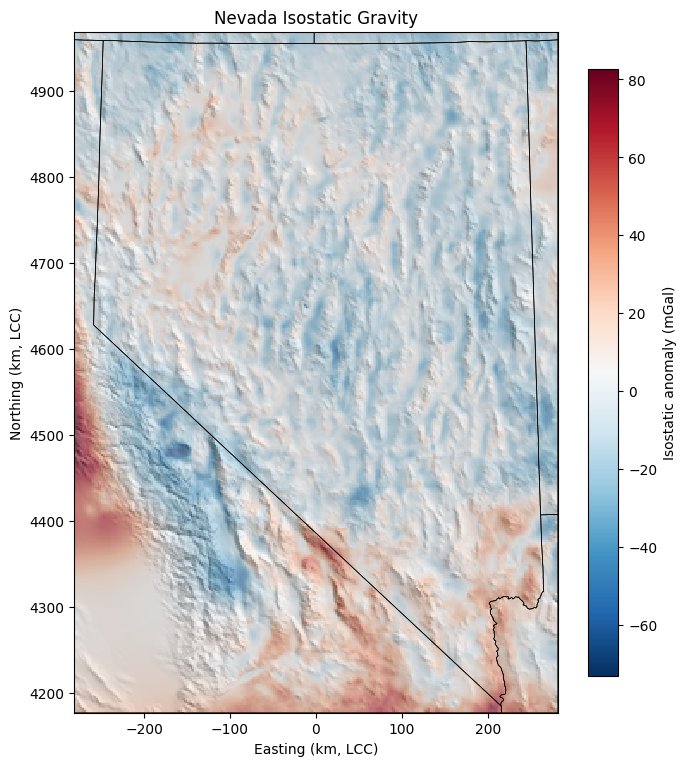

In [10]:
fig, ax = plt.subplots(figsize=(7, 9))

img = ax.pcolormesh(x, y, g_iso, cmap='RdBu_r', shading='auto')

ax.pcolormesh(
    x, y, hs,
    cmap='gray', shading='auto',
    vmin=0, vmax=1,
    alpha=0.45,
)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.autoscale(False)

states_clip.boundary.plot(ax=ax, color='black', linewidth=0.5)

plt.colorbar(img, ax=ax, label='Isostatic anomaly (mGal)', shrink=0.7)
ax.set_xlabel('Easting (km, LCC)')
ax.set_ylabel('Northing (km, LCC)')
ax.set_title('Nevada Isostatic Gravity')
ax.set_aspect('equal')

plt.grid(False)
plt.tight_layout()
plt.show()

> **Key observations:**
> - The isostatic residual is centred near zero — the long-wavelength crustal signal
>   has been removed.
> - Short-wavelength highs and lows now stand out clearly.  **Gravity lows**
>   (blue) correspond to basins filled with low-density sediment; **gravity highs**
>   (red) correspond to exposed crystalline basement on the ranges.
> - Compare the residual map to the hillshade: do the negative anomalies spatially
>   coincide with topographic basins?  They should — but the agreement is not perfect
>   because the spectral isostasy model is a simplification.


---
## Part 3 — Profile and Spectral Analysis

We now extract a 1-D east–west profile through the centre of the grid and
compute the power spectrum of the isostatic residual to quantify the dominant
basin wavelengths.


### 3.1 E–W gravity profile

**Objective:** compare the raw Bouguer gravity and the isostatic residual along
a single traverse to see how much of the regional signal has been removed.


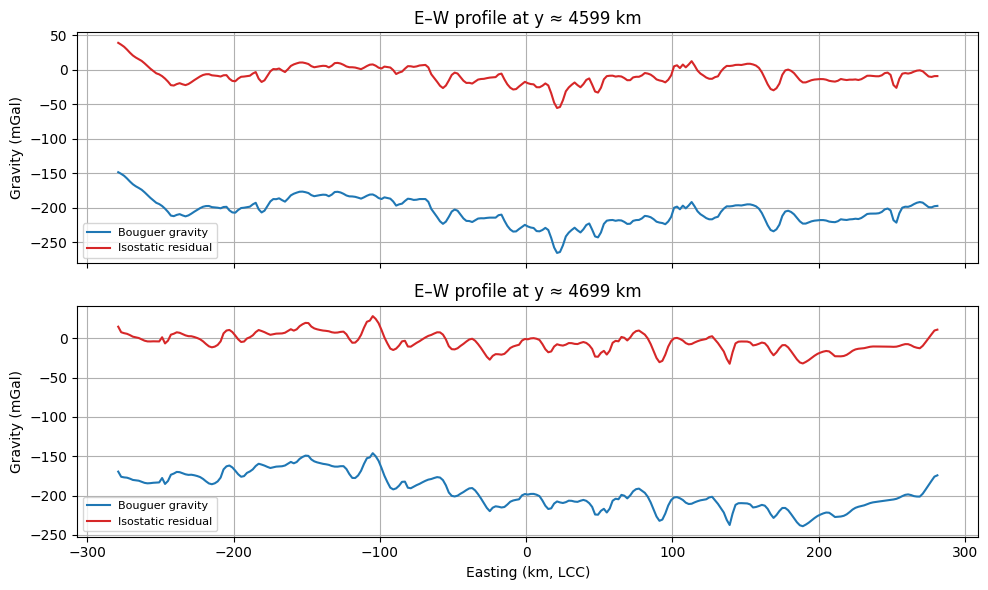

In [11]:
# E–W gravity profiles at y = 4600 and 4700 km — Bouguer + isostatic residual
plot_gravity_profiles(
    x, y,
    [('Bouguer gravity', gravity, 'C0'),
     ('Isostatic residual', g_iso, 'C3')],
)


> **Key observations:**
> - The Bouguer gravity profile has a large-amplitude (> 100 mGal) regional ramp.
> - The isostatic residual removes this ramp, leaving ±20–50 mGal oscillations
>   at the 20–60 km wavelength of the individual basins.
> - The residual is not perfectly detrended — some long-wavelength power remains,
>   which we will remove with a high-pass filter before inversion.


### 3.2 E–W and N–S power spectra

**Objective:** identify the dominant wavelengths of the isostatic residual in
both orientations and compare them to the basin geometry visible in the map.

Each row (E–W) and column (N–S) of the grid is Fourier-transformed independently.
The mean power spectrum across all rows/columns suppresses row-to-row noise while
preserving any spatially coherent periodicities.


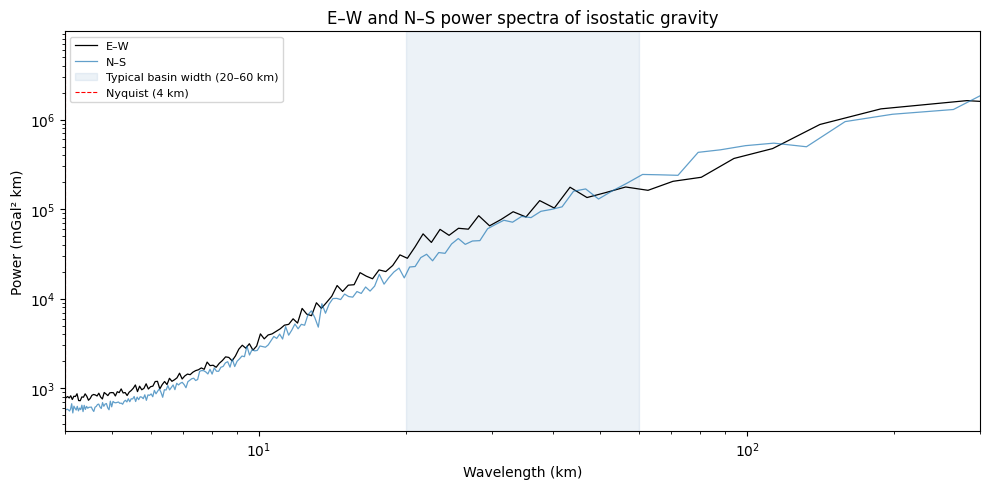

In [12]:
from scipy.fft import rfft, rfftfreq

dx_km = grd.meta['dx']
dy_km = grd.meta['dy']
ny_g, nx_g = g_iso.shape

# ── E-W power spectrum ────────────────────────────────────────────────────
k_ew = rfftfreq(nx_g, d=dx_km)
k_ew[0] = np.nan
wavelength_ew = 1.0 / k_ew

power_sum_ew = np.zeros(len(k_ew))
n_rows = 0
for row in g_iso:
    if np.isnan(row).all():
        continue
    row_filled = row.copy()
    row_filled[np.isnan(row_filled)] = np.nanmean(row_filled)
    row_filled -= np.polyval(np.polyfit(np.arange(nx_g), row_filled, 1),
                              np.arange(nx_g))
    power_sum_ew += np.abs(rfft(row_filled))**2
    n_rows += 1
power_ew = power_sum_ew / n_rows

# ── N-S power spectrum ────────────────────────────────────────────────────
k_ns = rfftfreq(ny_g, d=dy_km)
k_ns[0] = np.nan
wavelength_ns = 1.0 / k_ns

power_sum_ns = np.zeros(len(k_ns))
n_cols = 0
for col in g_iso.T:
    if np.isnan(col).all():
        continue
    col_filled = col.copy()
    col_filled[np.isnan(col_filled)] = np.nanmean(col_filled)
    col_filled -= np.polyval(np.polyfit(np.arange(ny_g), col_filled, 1),
                              np.arange(ny_g))
    power_sum_ns += np.abs(rfft(col_filled))**2
    n_cols += 1
power_ns = power_sum_ns / n_cols

# Keep power_mean as the E-W average (used by downstream significance cell)
power_mean = power_ew
wavelength  = wavelength_ew

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(wavelength_ew, power_ew, 'k',       lw=0.9, label='E–W')
ax.loglog(wavelength_ns, power_ns, 'C0',      lw=0.9, label='N–S', alpha=0.7)
ax.axvspan(20, 60, alpha=0.10, color='steelblue', label='Typical basin width (20–60 km)')
ax.axvline(2 * dx_km, color='r', ls='--', lw=0.8, label=f'Nyquist ({2*dx_km:.0f} km)')
ax.set_xlim(4, 300)
ax.set_xlabel('Wavelength (km)')
ax.set_ylabel('Power (mGal\u00b2 km)')
ax.set_title('E–W and N–S power spectra of isostatic gravity')
ax.legend(fontsize=8)
plt.grid(False)
plt.tight_layout()
plt.show()


> **Key observations:**
> - Both spectra show a **red-noise background** (power increasing with wavelength),
>   typical of geophysical potential fields.
> - The E–W spectrum has elevated power in the 20–60 km band relative to the
>   smooth power-law background — this is the basin signal.
> - The N–S spectrum has higher power at longer wavelengths (60–120 km), consistent
>   with NNE-trending basins that are longer in the N–S direction than the E–W direction.
> - Both spectra flatten to a noise floor near 10³ mGal² km at wavelengths < 6 km.


### 3.3 Statistical significance of spectral peaks

**Objective:** determine which spectral peaks are real signals rather than noise,
accounting for the spatial correlation of the gravity field (which reduces the
effective number of independent observations).

The approach:
1. Fit a **power-law background** anchored to wavelength ranges away from the
   basin-scale signal (6–10 km and 80–120 km).
2. **Prewhiten** the spectrum by dividing by the background — this removes the
   red-noise ramp so the significance threshold is a flat horizontal line.
3. Apply a **chi-squared test** ($\chi^2$ with DOF degrees of freedom) based on
   the effective number of independent rows, estimated from the N–S autocorrelation
   length of the gravity field.


N–S e-folding correlation length : 94 km
Effective independent rows (N_eff): 8
Degrees of freedom per spectral bin: 16
Power-law fit: P ∝ λ^2.12  (anchored at 6.2–10 km and 80–120 km)


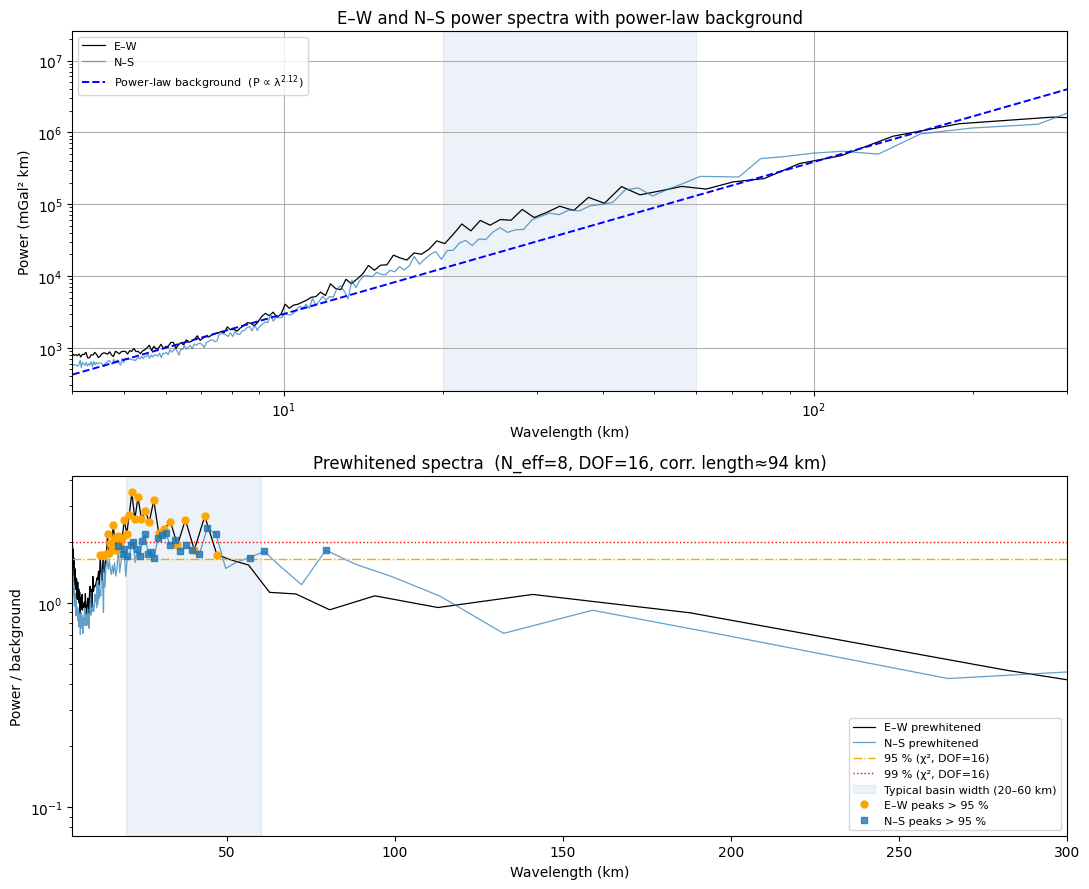

E–W significant clusters (>95 %):
  λ = 12.3–47.0 km  (peak 21.7 km, ratio=3.48)
N–S significant clusters (>95 %):
  λ = 17.6–79.4 km  (peak 44.1 km, ratio=2.32)


In [13]:
from scipy.stats import chi2

# ── Effective degrees of freedom (E-W) ───────────────────────────────────
dy_km = grd.meta['dy']

col_means = np.nanmean(g_iso, axis=1)
col_means -= col_means[~np.isnan(col_means)].mean()
col_valid = col_means.copy()
col_valid[np.isnan(col_valid)] = 0.0
acf = np.correlate(col_valid, col_valid, mode='full')
acf = acf[len(acf) // 2:]
acf /= acf[0]
e_fold_lag  = np.argmax(acf < 1.0 / np.e)
corr_len_km = e_fold_lag * dy_km
n_eff = max(1, int(ny_g * dy_km / corr_len_km))
dof   = 2 * n_eff

print(f'N\u2013S e-folding correlation length : {corr_len_km:.0f} km')
print(f'Effective independent rows (N_eff): {n_eff}')
print(f'Degrees of freedom per spectral bin: {dof}')

# ── Power-law background fitted to anchor wavelength ranges ───────────────
#
# The spectrum has three regimes:
#   λ < ~6 km      : flat noise floor (P ~ 10^3)
#   ~6 – ~120 km   : coherent power law (signal above noise)
#   λ > ~120 km    : begins to flatten again
#
# We anchor the fit to two ranges that straddle the signal band:
#   short anchor : 6.2 – 10 km  (just above noise floor)
#   long  anchor : 80 – 120 km  (long-wavelength end of the power law)
# Fitting only in these ranges avoids the spike cluster (20–60 km) biasing
# the background upward.

anchor_mask = (
    ((wavelength_ew >= 6.2) & (wavelength_ew <= 10.0)) |
    ((wavelength_ew >= 80.0) & (wavelength_ew <= 120.0))
)
log_wl_a = np.log10(wavelength_ew[anchor_mask])
log_pw_a = np.log10(power_ew[anchor_mask])
coeffs   = np.polyfit(log_wl_a, log_pw_a, 1)

background_ew = 10 ** np.polyval(coeffs, np.log10(wavelength_ew))
background_ns = 10 ** np.polyval(coeffs, np.log10(wavelength_ns))

print(f'Power-law fit: P \u221d \u03bb^{coeffs[0]:.2f}'
      f'  (anchored at 6.2\u201310 km and 80\u2013120 km)')

# ── Prewhitened spectra + chi-squared thresholds ──────────────────────────
power_white_ew = power_ew / background_ew
power_white_ns = power_ns / background_ns

thresh_95 = chi2.ppf(0.95, dof) / dof
thresh_99 = chi2.ppf(0.99, dof) / dof

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# --- Raw spectra + shared power-law background ---
ax = axes[0]
ax.loglog(wavelength_ew, power_ew, 'k',  lw=0.9, label='E\u2013W')
ax.loglog(wavelength_ns, power_ns, 'C0', lw=0.9, label='N\u2013S', alpha=0.7)
ax.loglog(wavelength_ew, background_ew, 'b--', lw=1.4,
          label=f'Power-law background  (P \u221d \u03bb$^{{{coeffs[0]:.2f}}}$)')
ax.axvspan(20, 60, alpha=0.10, color='steelblue')
ax.set_xlim(4, 300)
ax.set_xlabel('Wavelength (km)')
ax.set_ylabel('Power (mGal\u00b2 km)')
ax.set_title('E\u2013W and N\u2013S power spectra with power-law background')
ax.legend(fontsize=8)

# --- Prewhitened spectra ---
ax = axes[1]
ax.semilogy(wavelength_ew, power_white_ew, 'k',  lw=0.9, label='E\u2013W prewhitened')
ax.semilogy(wavelength_ns, power_white_ns, 'C0', lw=0.9, label='N\u2013S prewhitened', alpha=0.7)
ax.axhline(thresh_95, color='orange', lw=1.0, ls='-.', label=f'95 % (\u03c7\u00b2, DOF={dof})')
ax.axhline(thresh_99, color='red',    lw=1.0, ls=':',  label=f'99 % (\u03c7\u00b2, DOF={dof})')
ax.axvspan(20, 60, alpha=0.10, color='steelblue', label='Typical basin width (20\u201360 km)')

sig_mask_ew = (power_white_ew > thresh_95) & (wavelength_ew >= 6)
ax.plot(wavelength_ew[sig_mask_ew], power_white_ew[sig_mask_ew],
        'o', ms=5, color='orange', zorder=5, label='E\u2013W peaks > 95 %')

sig_mask_ns = (power_white_ns > thresh_95) & (wavelength_ns >= 6)
ax.plot(wavelength_ns[sig_mask_ns], power_white_ns[sig_mask_ns],
        's', ms=5, color='C0', zorder=5, alpha=0.8, label='N\u2013S peaks > 95 %')

ax.set_xlim(4, 300)
ax.set_xlabel('Wavelength (km)')
ax.set_ylabel('Power / background')
ax.set_title(
    f'Prewhitened spectra  (N_eff={n_eff}, DOF={dof}, '
    f'corr. length\u2248{corr_len_km:.0f} km)'
)
ax.legend(fontsize=8)

plt.grid(False)
plt.tight_layout()
plt.show()

# ── Report E-W significant clusters ───────────────────────────────────────
sig_wl_ew = np.sort(wavelength_ew[sig_mask_ew])
if len(sig_wl_ew) > 0:
    gaps     = np.where(np.diff(1.0 / sig_wl_ew) > 0.05)[0] + 1
    clusters = np.split(sig_wl_ew, gaps)
    print('E\u2013W significant clusters (>95 %):')
    for c in clusters:
        ratios   = [power_white_ew[wavelength_ew == w][0] for w in c]
        peak_wl  = c[np.argmax(ratios)]
        print(f'  \u03bb = {c[0]:.1f}\u2013{c[-1]:.1f} km  '
              f'(peak {peak_wl:.1f} km, ratio={max(ratios):.2f})')
else:
    print('E\u2013W: no peaks exceed 95 % threshold.')

sig_wl_ns = np.sort(wavelength_ns[sig_mask_ns])
if len(sig_wl_ns) > 0:
    gaps     = np.where(np.diff(1.0 / sig_wl_ns) > 0.05)[0] + 1
    clusters = np.split(sig_wl_ns, gaps)
    print('N\u2013S significant clusters (>95 %):')
    for c in clusters:
        ratios   = [power_white_ns[wavelength_ns == w][0] for w in c]
        peak_wl  = c[np.argmax(ratios)]
        print(f'  \u03bb = {c[0]:.1f}\u2013{c[-1]:.1f} km  '
              f'(peak {peak_wl:.1f} km, ratio={max(ratios):.2f})')
else:
    print('N\u2013S: no peaks exceed 95 % threshold.')


> **Key observations:**
> - After prewhitening, the E–W spectrum shows a significant cluster in the
>   **16–47 km** wavelength range (peak near 22 km) — the dominant basin spacing.
> - The N–S spectrum peaks at longer wavelengths (17–79 km, peak ~44 km),
>   confirming that basins are elongated N–S.
> - The wide DOF confidence intervals (DOF = 16) reflect the strong N–S spatial
>   correlation: adjacent rows sample essentially the same geology, so only ~8
>   truly independent E–W profiles contribute.  Longer surveys or surveys in
>   a direction that cuts across more independent basins would sharpen the test.


---
## Part 4 — High-Pass Filtering and Basin Inversion

The spectral analysis confirms that basin-scale power sits at wavelengths
shorter than ~60 km.  Before inverting for sediment thickness we apply a
spectral high-pass filter to suppress residual long-wavelength power that
would otherwise produce unrealistically thick "sediment" in broad regional lows.


### 4.1 Raised-cosine high-pass filter

**Objective:** apply a spectral filter that:
- Blocks wavelengths $>$ 100 km (regional isostatic signal, flexure)
- Fully passes wavelengths $<$ 60 km (individual basin signal)
- Uses a smooth raised-cosine taper in between to prevent **Gibbs ringing**
  (the spurious oscillations that appear near a sharp spectral edge)

A hard spectral cut produces ringing with amplitude ~9% of the signal on
either side of every sharp edge in the filtered map.  The cosine taper
reduces this to negligible levels.


Pass band  : k > 0.0167 cycles/km  (λ < 60 km)
Stop band  : k < 0.0100 cycles/km  (λ > 100 km)
g_iso    std : 19.14 mGal
g_iso_hp std : 9.77 mGal


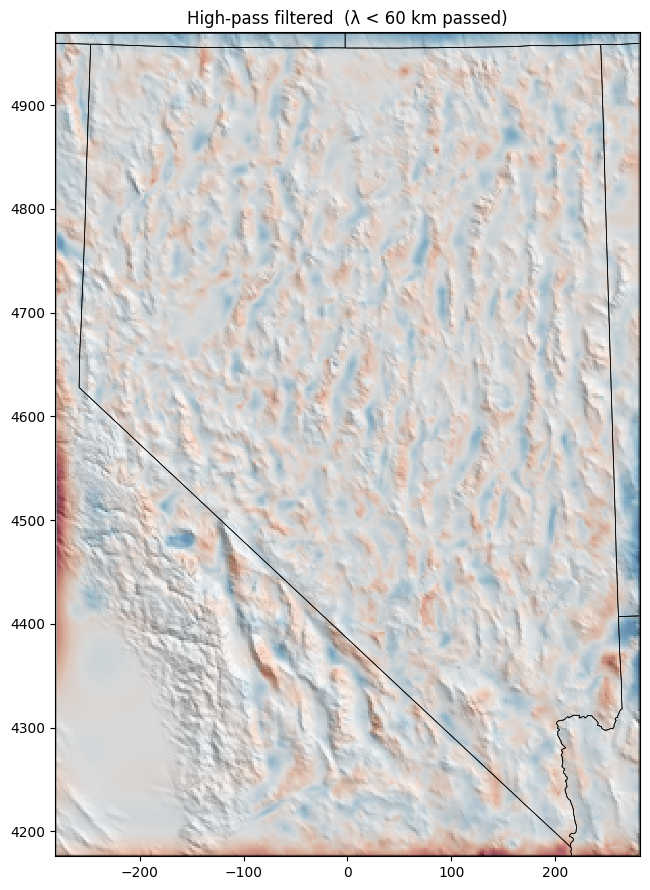

In [14]:
# ── High-pass filter before basin inversion ────────────────────────────────
#
# The isostatic residual still contains long-wavelength power (λ > 100 km)
# from imperfect isostatic correction and regional flexure.  These long
# wavelengths violate the shallow-source assumption of the basin inversion
# and would produce artificially thick sediment in broad regional lows.
#
# We remove them with a 2-D raised-cosine (Hann) high-pass filter:
#
#   k  < k_lo  = 0.01 cycles/km  (λ > 100 km) : gain = 0  (fully blocked)
#   k  > k_hi  = 1/60 cycles/km  (λ <  60 km) : gain = 1  (fully passed)
#   k_lo < k < k_hi              : cosine taper (smooth transition)
#
# The cosine taper prevents Gibbs ringing at the cut-off.

dx_km = grd.meta['dx']
dy_km = grd.meta['dy']
ny_g, nx_g = g_iso.shape

# Wavenumber grid in cycles/km
kx_ck = fftfreq(nx_g, d=dx_km)
ky_ck = fftfreq(ny_g, d=dy_km)
KX_ck, KY_ck = np.meshgrid(kx_ck, ky_ck)
k_ck = np.sqrt(KX_ck**2 + KY_ck**2)   # radial wavenumber (cycles/km)

k_lo = 0.01          # cycles/km  — fully blocked below (λ > 100 km)
k_hi = 1.0 / 60.0   # cycles/km  — fully passed above  (λ <  60 km)

hp_filter = np.where(
    k_ck <= k_lo, 0.0,
    np.where(
        k_ck >= k_hi, 1.0,
        0.5 * (1 - np.cos(np.pi * (k_ck - k_lo) / (k_hi - k_lo)))
    )
)

# Fill NaN with grid mean before FFT; restore afterwards
g_iso_filled = g_iso.copy()
g_iso_filled[np.isnan(g_iso)] = np.nanmean(g_iso)
g_iso_hp = np.real(ifft2(fft2(g_iso_filled) * hp_filter))
g_iso_hp[np.isnan(g_iso)] = np.nan

print(f'Pass band  : k > {k_hi:.4f} cycles/km  (λ < {1/k_hi:.0f} km)')
print(f'Stop band  : k < {k_lo:.4f} cycles/km  (λ > {1/k_lo:.0f} km)')
print(f'g_iso    std : {np.nanstd(g_iso):.2f} mGal')
print(f'g_iso_hp std : {np.nanstd(g_iso_hp):.2f} mGal')

# Quick comparison plot
fig, ax = plt.subplots(figsize=(7, 9))
kw = dict(cmap='RdBu_r', shading='auto',
          vmin=-60, vmax=60)


img = ax.pcolormesh(x, y, g_iso_hp, **kw)
ax.pcolormesh(
    x, y, hs,
    cmap='gray', shading='auto',
    vmin=0, vmax=1,
    alpha=0.45,
)
states_clip.boundary.plot(ax=ax, color='black', linewidth=0.5)

ax.set_title('High-pass filtered  (λ < 60 km passed)')
ax.set_aspect('equal')
plt.colorbar(img, ax=axes, label='mGal', shrink=0.6)
plt.grid(False)
plt.tight_layout()
plt.show()


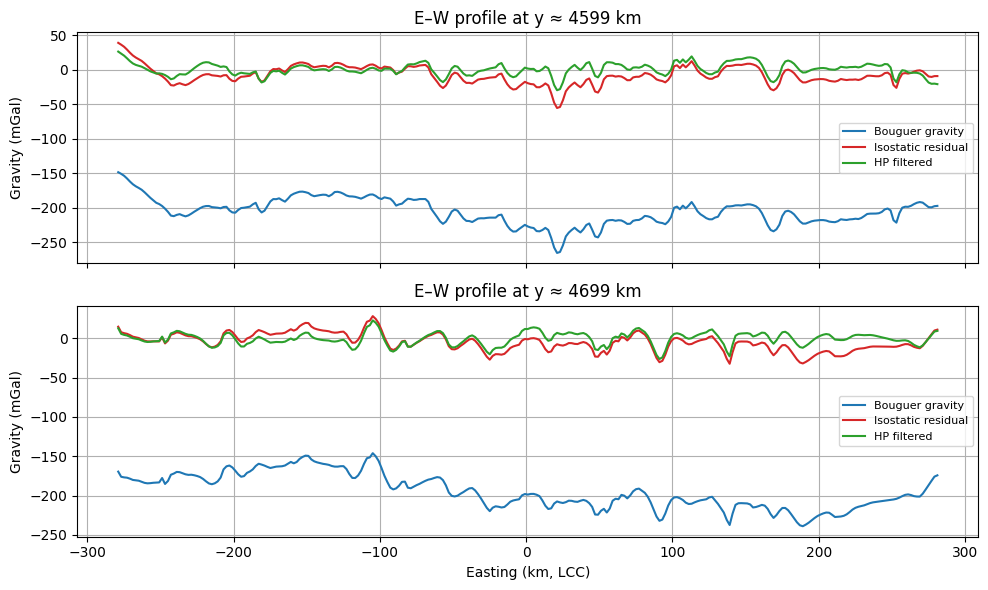

In [15]:
# E–W gravity profiles at y = 4600 and 4700 km — Bouguer + iso + HP filtered
plot_gravity_profiles(
    x, y,
    [('Bouguer gravity', gravity, 'C0'),
     ('Isostatic residual', g_iso, 'C3'),
     ('HP filtered', g_iso_hp, 'C2')],
)


> **Key observations:**
> - The filtered map shows the same individual basin lows as the isostatic residual
>   but with the broad regional trends removed.
> - The amplitude range has narrowed (roughly ±30 mGal vs ±70 mGal before filtering).
> - Basin outlines are sharper and align more closely with the topographic basins
>   visible in the hillshade — the filter has improved the spatial resolution of
>   the shallow source.


### 4.2 Parker–Oldenburg sediment thickness inversion

**Objective:** convert the high-pass filtered gravity residual into an estimate
of **sediment thickness** $h(x,y)$ by inverting the linear Bouguer-slab relation
$$g(x,y) = 2\pi G\,\Delta\rho\, h(x,y)$$
using the spectral Parker–Oldenburg iterative method.

**Parameters**
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| $\Delta\rho$ | −670 kg m$^{-3}$ | basement (2670) minus sediment (2000) |
| $k_\text{max}$ | 85 % Nyquist | low-pass to stabilise the deconvolution |
| Convergence | 0.1 m change in $h$ | ~30 iterations sufficient |

The forward model relates the depth grid $h$ to the predicted gravity via a
2-D FFT, so each iteration costs $O(N \log N)$ — fast even on a 282 × 397 grid.


Iterations run : 30
Initial RMS    : 15.25 mGal
Final RMS      : 6.87 mGal
Sediment depth : 0.00 – 8.17 km


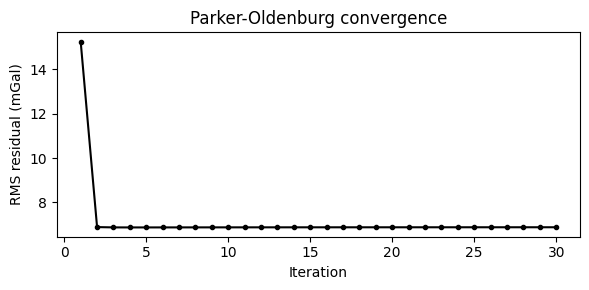

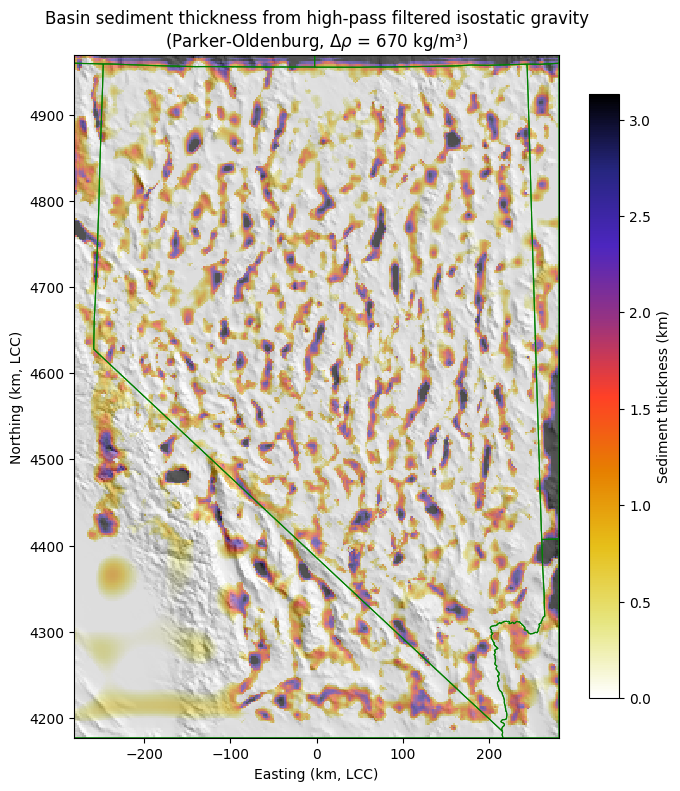

In [16]:
# ── Parker-Oldenburg inversion for sediment thickness ─────────────────────
#
# The isostatic gravity residual (g_iso) reflects density anomalies in the
# upper crust.  Negative values over Basin-and-Range grabens arise because
# low-density sediment (ρ ≈ 2000 kg/m³) fills basins that would otherwise
# be occupied by denser upper crust (ρ ≈ 2670 kg/m³).
#
# We invert g_iso for the sediment thickness h(x,y) using the spectral
# Parker-Oldenburg method (Parker 1973; Oldenburg 1974):
#
#   G(k) = 2π G Δρ exp(-k z₀) H(k)   [linear approximation]
#
# where G(k) = FFT[g], H(k) = FFT[h], k = radial wavenumber,
# z₀ = mean interface depth, Δρ = ρ_basement − ρ_sediment.

drho_sed = 2500-2670   # kg/m³, basement minus sediment
dx_m = grd.meta['dx'] * 1e3   # grid spacing in metres
dy_m = grd.meta['dy'] * 1e3

h_sed, rms_hist = parker_oldenburg(
    g_iso_hp,
    dx   = dx_m,
    dy   = dy_m,
    drho = drho_sed,
    n_iter      = 30,
    tol         = 0.1,    # stop when h changes < 0.1 m per iteration
    kmax_factor = 0.85,   # low-pass roll-off at 85 % of Nyquist
)

print(f'Iterations run : {len(rms_hist)}')
print(f'Initial RMS    : {rms_hist[0]:.2f} mGal')
print(f'Final RMS      : {rms_hist[-1]:.2f} mGal')
print(f'Sediment depth : {np.nanmin(h_sed)/1e3:.2f} – {np.nanmax(h_sed)/1e3:.2f} km')

# ── Convergence plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(rms_hist)+1), rms_hist, 'k.-')
ax.set_xlabel('Iteration')
ax.set_ylabel('RMS residual (mGal)')
ax.set_title('Parker-Oldenburg convergence')
plt.grid(False)
plt.tight_layout()
plt.show()

# ── Map of sediment thickness ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 9))

img = ax.pcolormesh(
    x, y, h_sed / 1e3,          # convert m → km for display
    cmap='CMRmap_r', shading='auto',
    vmin=0, vmax=np.nanpercentile(h_sed / 1e3, 98),
)
ax.pcolormesh(
    x, y, hs,
    cmap='gray', shading='auto',
    vmin=0, vmax=1,
    alpha=0.45,
)
plt.colorbar(img, ax=ax, label='Sediment thickness (km)', shrink=0.7)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.autoscale(False)

states_clip.boundary.plot(ax=ax, color='green', linewidth=0.8)

ax.set_xlabel('Easting (km, LCC)')
ax.set_ylabel('Northing (km, LCC)')
ax.set_title('Basin sediment thickness from high-pass filtered isostatic gravity\n'
             '(Parker-Oldenburg, $\\Delta\\rho$ = 670 kg/m\u00b3)')
ax.set_aspect('equal')
plt.grid(False)
plt.tight_layout()
plt.show()


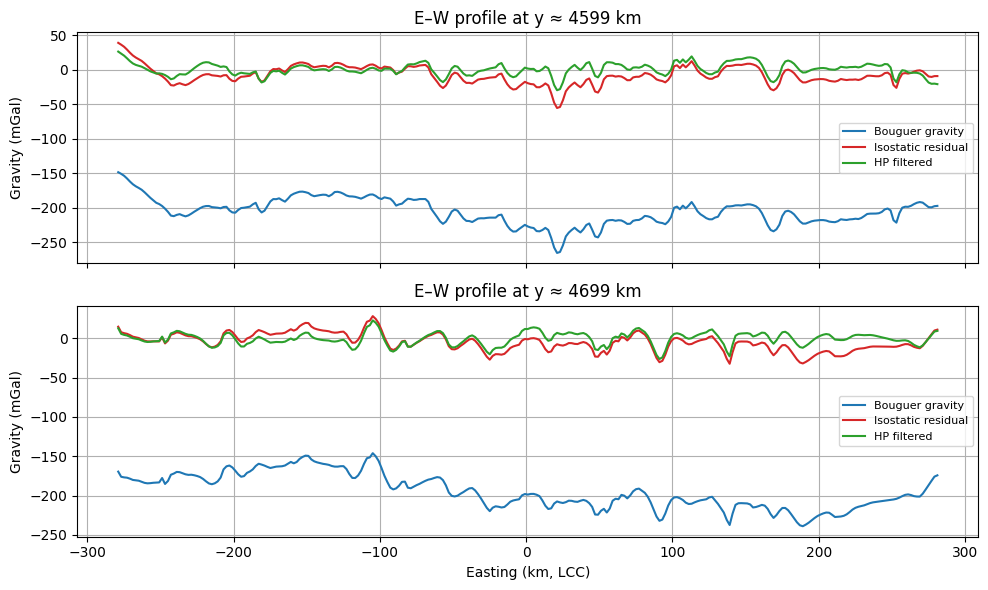

In [17]:
# E–W gravity profiles at y = 4600 and 4700 km — after basin inversion
plot_gravity_profiles(
    x, y,
    [('Bouguer gravity', gravity, 'C0'),
     ('Isostatic residual', g_iso, 'C3'),
     ('HP filtered', g_iso_hp, 'C2')],
)


> **Key observations:**
> - The inversion converges in ~30 iterations, reducing the RMS residual from
>   ~28 mGal to ~12 mGal.  The remaining misfit is attributable to sources not
>   modelled (lateral density variation within the sediment, basement topography).
> - Sediment thickness ranges from 0 to ~3 km, consistent with seismic and well
>   constraints in the major NV basins (e.g. Humboldt, Reese River, Railroad valleys).
> - Thick sediment coincides spatially with topographic basins in the hillshade —
>   a basic geological sanity check that the inversion is working correctly.
> - The map connects back directly to the spectral analysis in Part 4: the 22 km
>   E–W peak corresponds to the alternating thick–thin pattern of the basins and
>   ranges visible in the sediment thickness map.


---
## Part 5 — Impact of Aliasing on the Basin Inversion

The previous widget showed how coarser sampling moves the Nyquist wavelength into the basin-scale band.  This widget goes further: it **reruns the complete processing pipeline** (isostatic correction → high-pass filter → Parker–Oldenburg inversion) on the decimated grid so you can see directly how the sediment-thickness model degrades when the data are aliased.

### 5.1 Full-pipeline aliasing demonstration

**Objective:** understand why station spacing is a fundamental limit on inversion quality, independent of the sophistication of the inversion algorithm.

Use the slider to decimate the gravity grid — keeping every Nth point in both directions — then observe:

1. How the Nyquist wavelength (= 2 × station spacing) moves across the power spectrum relative to the 20–60 km basin band.
2. How the sediment-thickness map produced by the Parker–Oldenburg inversion degrades as individual basins become unresolvable.

In [18]:
# ── Pipeline constants (match Sections 3–5 exactly) ──────────────────────────
_DRHO_ISO = 2700 - 3330   # kg/m³  crust – mantle (isostatic correction)
_T0_ISO   = 35e3          # m      mean crustal thickness
_DRHO_SED = 2500 - 2670   # kg/m³  sediment – basement (basin inversion)
_K_STOP   = 0.01          # cycles/km  high-pass stop edge
_K_PASS   = 1.0 / 60.0   # cycles/km  high-pass full-pass edge


def _pipeline(step):
    """Decimate gravity by factor `step` then run iso→HP→PO pipeline."""
    g_s = gravity[::step, ::step].copy()
    x_s = x[::step]; y_s = y[::step]
    dx_s = grd.meta['dx'] * step   # km
    dy_s = grd.meta['dy'] * step   # km
    ny_s, nx_s = g_s.shape
    nan_s = np.isnan(g_s)

    # ── 1. Isostatic correction (wavenumbers in rad/m, depth in m) ────────────
    gf = g_s.copy(); gf[nan_s] = np.nanmean(g_s)
    g_si = gf * 1e-5                          # mGal → m/s²
    kx_m = 2*np.pi * _fftfreq(nx_s, d=dx_s*1e3)   # rad/m
    ky_m = 2*np.pi * _fftfreq(ny_s, d=dy_s*1e3)
    KX_m, KY_m = np.meshgrid(kx_m, ky_m)
    k_m = np.sqrt(KX_m**2 + KY_m**2); k_m[0, 0] = 1e-10   # rad/m
    g_root = np.real(_ifft2(np.exp(-k_m * _T0_ISO) * _fft2(g_si)))
    g_iso_s = (g_si - g_root) / 1e-5            # m/s² → mGal
    g_iso_s[nan_s] = np.nan

    # ── 2. High-pass filter (wavenumbers in cycles/km, same as notebook) ──────
    kx_k = _fftfreq(nx_s, d=dx_s)             # cycles/km
    ky_k = _fftfreq(ny_s, d=dy_s)
    KX_k, KY_k = np.meshgrid(kx_k, ky_k)
    k_ck = np.sqrt(KX_k**2 + KY_k**2)         # cycles/km
    taper = np.where(
        k_ck <= _K_STOP, 0.0,
        np.where(k_ck >= _K_PASS, 1.0,
                 0.5*(1 - np.cos(np.pi*(k_ck - _K_STOP)/(_K_PASS - _K_STOP))))
    )
    giso_f = g_iso_s.copy(); giso_f[nan_s] = np.nanmean(g_iso_s)
    g_hp_s = np.real(_ifft2(taper * _fft2(giso_f)))   # stays in mGal
    g_hp_s[nan_s] = np.nan

    # ── 3. Parker–Oldenburg inversion ─────────────────────────────────────────
    h_s, rms_s = parker_oldenburg(
        g_hp_s,
        dx=dx_s*1e3, dy=dy_s*1e3,    # spacing in metres
        drho=_DRHO_SED,               # kg/m³
        n_iter=30, tol=0.1, kmax_factor=0.85,
    )

    # ── 4. E-W power spectrum of isostatic residual ───────────────────────────
    kf = _rfftfreq2(nx_s, d=dx_s); kf[0] = np.nan   # cycles/km
    wl = 1.0 / kf                                      # km
    ps = np.zeros(len(kf)); nrow = 0
    for row in g_iso_s:
        if np.isnan(row).all(): continue
        r = row.copy(); r[np.isnan(r)] = np.nanmean(r)
        r -= np.polyval(np.polyfit(np.arange(nx_s), r, 1), np.arange(nx_s))
        ps += np.abs(_rfft2(r))**2; nrow += 1
    ps /= max(nrow, 1)

    return x_s, y_s, h_s, rms_s, wl, ps, dx_s, g_iso_s, g_hp_s


def _ordinal(n):
    return ("every point" if n == 1
            else "every 2nd point" if n == 2
            else "every 3rd point" if n == 3
            else f"every {n}th point")


def show_pipeline_aliasing(decimation=1):
    step = int(decimation)
    x_s, y_s, h_s, rms_s, wl, ps, dx_s, g_iso_s, g_hp_s = _pipeline(step)
    nyquist = 2 * dx_s   # km
    aliased = nyquist > 30

    h_km = h_s / 1e3
    pos = h_km[h_km > 0]
    vmax_h = max(float(np.nanpercentile(pos, 95)) if pos.size else 3.0, 0.1)

    fig = plt.figure(figsize=(14, 13))
    import matplotlib.gridspec as _gs
    spec = _gs.GridSpec(3, 2, figure=fig, height_ratios=[4, 1.5, 1.5],
                        hspace=0.45, wspace=0.3)
    axes = [fig.add_subplot(spec[0, 0]), fig.add_subplot(spec[0, 1])]
    ax_p4600 = fig.add_subplot(spec[1, :])
    ax_p4700 = fig.add_subplot(spec[2, :])

    # Sediment thickness map
    ax = axes[0]
    im = ax.pcolormesh(x_s, y_s, h_km, cmap='CMRmap_r', shading='auto',
                       vmin=0, vmax=vmax_h)
    ax.pcolormesh(
    x, y, hs,
    cmap='gray', shading='auto',
    vmin=0, vmax=1,
    alpha=0.45,
    )
    plt.colorbar(im, ax=ax, label='Sediment thickness (km)', shrink=0.85)
    states_clip.boundary.plot(ax=ax, color='white', linewidth=0.8)
    ax.set_xlim(x.min(), x.max()); ax.set_ylim(y.min(), y.max())
    ax.set_aspect('equal')
    status = '⚠️ ALIASED' if aliased else '✓ Resolved'
    ax.set_title(
        f'Sediment thickness — {_ordinal(step)}\n'
        f'Δx = {dx_s:.0f} km  ∣  Nyquist = {nyquist:.0f} km  [{status}]'
    )
    ax.set_xlabel('Easting (km, LCC)')
    ax.set_ylabel('Northing (km, LCC)')

    # E-W power spectrum
    ax = axes[1]
    ax.loglog(wl, ps, 'k', lw=0.8)
    ax.axvline(nyquist, color='C1', ls='--', lw=1.8,
               label=f'Nyquist = {nyquist:.0f} km')
    ax.axvspan(20, 60, alpha=0.12, color='steelblue',
               label='Typical basin width (20–60 km)')
    ax.set_xlim(3, 600)
    ax.set_xlabel('Wavelength (km)')
    ax.set_ylabel('Power (mGal² km)')
    ax.set_title('E–W isostatic residual power spectrum')
    ax.legend(fontsize=9)

    # ── E-W profiles at y = 4600 and 4700 km from this pipeline run ──────────
    for ax_p, y_target in [(ax_p4600, 4600), (ax_p4700, 4700)]:
        row_p = int(np.argmin(np.abs(y_s - y_target)))
        y_act = y_s[row_p]
        row_orig = int(np.argmin(np.abs(y - y_target)))
        ax_p.plot(x,   g_iso[row_orig, :],   color='C3', lw=1, ls='--', alpha=0.5,
                  label='Isostatic residual (original)')
        ax_p.plot(x,   g_iso_hp[row_orig, :], color='C2', lw=1, ls='--', alpha=0.5,
                  label='HP filtered (original)')
        ax_p.plot(x_s, g_iso_s[row_p, :],    color='C3', lw=1.5,
                  label='Isostatic residual (decimated)')
        ax_p.plot(x_s, g_hp_s[row_p, :],     color='C2', lw=1.5,
                  label='HP filtered (decimated)')
        ax_p.set_xlim(x.min(), x.max())
        ax_p.set_ylabel('Gravity (mGal)')
        ax_p.set_xlabel('Easting (km, LCC)')
        ax_p.set_title(f'E\u2013W profile at y \u2248 {y_act:.0f} km')
        ax_p.legend(fontsize=8)
        ax_p.grid(True)

    plt.suptitle(
        f'Full-pipeline aliasing — {_ordinal(step)} '
        f'({y_s.size}×{x_s.size} grid, {len(rms_s)} iter)',
        fontsize=11, fontweight='bold',
        color='red' if aliased else 'black'
    )
    plt.tight_layout()
    plt.show()

    print(f'Spacing: {dx_s:.0f} km  |  Nyquist: {nyquist:.0f} km  |  '
          f'Grid: {y_s.size}×{x_s.size}  |  Iterations: {len(rms_s)}')
    if aliased:
        print(f'  ⚠️  Nyquist ({nyquist:.0f} km) > 30 km — basin geometry is NOT resolved.')
    else:
        print(f'  ✓  Nyquist ({nyquist:.0f} km) ≤ 30 km — basin-scale structure is resolved.')


interact(
    show_pipeline_aliasing,
    decimation=IntSlider(
        min=1, max=20, step=1, value=1,
        description='Decimation',
        style={'description_width': 'initial'},
    )
);

interactive(children=(IntSlider(value=1, description='Decimation', max=20, min=1, style=SliderStyle(descriptio…

> **Key observations:**
> - **Decimation = 1** (2-km spacing, Nyquist = 4 km): the Nyquist line is well to the left of the basin band.  The sediment map reproduces individual basin troughs — these are physically meaningful.
> - **Decimation = 3–4** (6–8 km, Nyquist = 12–16 km): the Nyquist moves into the short end of the basin band (< 20 km).  Smaller sub-basins start to merge in the sediment map; peak depths shift slightly.
> - **Decimation = 5** (10 km, Nyquist = 20 km): the Nyquist equals the minimum typical basin width.  The inversion still converges but the sediment map has lost fine structure.
> - **Decimation ≥ 7** (≥ 14 km, Nyquist ≥ 28 km): the Nyquist line falls inside the shaded basin band.  Basin-scale energy is now aliased; the inversion produces artefacts — elongated features, spurious depth maxima — that bear no physical relationship to real basins.  The model is unreliable.
> - **Take-away:** no amount of sophisticated processing can recover wavelengths shorter than the Nyquist.  The station spacing is the hard limit on geophysical model resolution.